In [375]:

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

import math
from time import time
from os import path




## 1

In [376]:
def gen_huff_table(simbolos, prob):
    nos = []
    # dicionario
    tabela = {s: "" for s in simbolos}
    
    
    for i in range(len(simbolos)):
        s = simbolos[i]   
        f = prob[i]  
        if f > 0:
            # Guardamos: [frequência, lista_de_símbolos]
            nos.append([f, [s]])
    
    while len(nos) > 1:
        #  Ordenar para encontrar os dois mais pequenos
        nos.sort(key=lambda x: x[0])
        
        #  Retirar os dois menos prováveis
        no1 = nos.pop(0)
        no2 = nos.pop(0)
        
        
        # Quem está no grupo 1 ganha um '0' no início do código
        for s in no1[1]:
            tabela[s] = '0' + tabela[s]
            
        # Quem está no grupo 2 ganha um '1' no início do código
        for s in no2[1]:
            tabela[s] = '1' + tabela[s]
            
        # Criar o novo nó (pai) e colocar de volta na lista[cite: 2]
        novo_no = [no1[0] + no2[0], no1[1] + no2[1]]
        nos.append(novo_no)
    
    # Retornamos apenas os símbolos que tinham probabilidade > 0
    return {s: c for s, c in tabela.items() if c != ""}

In [377]:
import pandas as pd

simb = ['a', 'b', 'c', 'd', 'e']
prob = [0.25, 0.25, 0.2, 0.15, 0.15]

resultado = gen_huff_table(simb, prob)

df = pd.DataFrame({
    "simbolo": simb,
     "codigo": [resultado[s] for s in simb],
    "probabilidade": prob,

})

print(df)

  simbolo codigo  probabilidade
0       a     01           0.25
1       b     10           0.25
2       c     00           0.20
3       d    110           0.15
4       e    111           0.15


## 2

In [378]:
def encode_huff(mensagem, tabela):
  
    sequencia_bits = ""
    
    # Percorrer cada símbolo na mensagem original
    for simbolo in mensagem:
        # buscar o código binário correspondente na tabela[cite: 1, 2]
        codigo = tabela[simbolo]
        
        
        sequencia_bits += codigo
        
    return sequencia_bits

In [379]:
mensagem_teste = ['a', 'b', 'a', 'c', 'd', 'e']
bits_codificados = encode_huff(mensagem_teste, resultado)



# 1. Criar um DataFrame com a mensagem na ordem real
df_sequencia = pd.DataFrame({"simbolo": mensagem_teste})

# 2. Mapear o tamanho de cada código (bits por símbolo)
df_sequencia["bits_individuais"] = df_sequencia["simbolo"].map(resultado).apply(len)

# 3. Calcular o TOTAL ACUMULADO (A "escada" do gráfico)
df_sequencia["total_acumulado"] = df_sequencia["bits_individuais"].cumsum()

print(df_sequencia)

  simbolo  bits_individuais  total_acumulado
0       a                 2                2
1       b                 2                4
2       a                 2                6
3       c                 2                8
4       d                 3               11
5       e                 3               14


## 3

In [380]:
def decode_huff(sequencia_bits, tabela_inversa):
    # Como a read_file já retorna a tabela invertida {codigo: simbolo},
    # a descodificação fica muito mais simples e rápida.
    mensagem = []
    buffer = ""
    for bit in sequencia_bits:
        buffer += bit
        if buffer in tabela_inversa:
            mensagem.append(tabela_inversa[buffer])
            buffer = ""
    return mensagem

## 4

In [381]:
def encode_table(tabela):
    """
    Codifica a tabela de Huffman conforme os requisitos do trabalho.
    Estrutura: [8 bits: num_simbolos] + [Simbolo + Tam_Codigo + Codigo]...
    """
    bits_tabela = ""
    
    # 1. Cabeçalho: Número de entradas na tabela (Ponto 6 do enunciado)
    # Usamos len(tabela) - 1 para que 256 símbolos caibam em 8 bits (0-255)
    num_entradas = len(tabela) - 1
    bits_tabela += format(num_entradas, '08b')
    
    for simbolo, codigo in tabela.items():
        # 2. Tratamento do Símbolo (8 bits)
        # Verifica se o símbolo é um número (imagem/áudio) ou caractere (texto)
        if isinstance(simbolo, (int, float)):
            valor_numerico = int(simbolo)
        elif isinstance(simbolo, str) and len(simbolo) == 1:
            valor_numerico = ord(simbolo)
        else:
            # Caso o símbolo venha como string numérica '65'
            valor_numerico = int(simbolo)
            
        simbolo_bin = format(valor_numerico, '08b')
        
        # 3. Tamanho do Código (5 bits)
        # Permite representar comprimentos de código até 31 bits
        tamanho_codigo = format(len(codigo), '05b')
        
        # 4. Concatenação: Símbolo + Tamanho + Código
        bits_tabela += simbolo_bin + tamanho_codigo + codigo
        
    return bits_tabela

## 5

In [382]:
def write2file(bits, nome):
    """
    Grava uma sequência de bits num ficheiro binário.
    O primeiro byte do ficheiro indica quantos bits de padding foram adicionados ao fim.
    """
    # Calcular quantos bits faltam para completar o último byte (múltiplo de 8)
    padding = (8 - len(bits) % 8) % 8
    
    # Adicionar os zeros de preenchimento
    b = bits + ('0' * padding)
    
    # Criar a lista de bytes: o primeiro elemento é o valor do padding
    lista_bytes = bytearray([padding]) 
    
    # Converter grupos de 8 bits em números inteiros (bytes)
    for i in range(0, len(b), 8):
        lista_bytes.append(int(b[i:i+8], 2))
    
    # Gravar o bytearray no ficheiro em modo 'write binary' (wb) 
    with open(nome, 'wb') as f:
        f.write(lista_bytes)

## 6

In [383]:
def read_file(ficheiro):
    with open(ficheiro, 'rb') as f:
        conteudo = f.read()
    
    # 1. Recuperar o padding (primeiro byte)
    padding = conteudo[0]
    
    # 2. Converter o restante para string de bits
    bits = "".join(format(b, '08b') for b in conteudo[1:])
    
    # 3. Remover os bits de preenchimento do final
    if padding > 0:
        bits = bits[:-padding]
    
    # 4. Ler o tamanho da tabela (8 bits iniciais da encode_table)
    # Adicionamos +1 porque gravamos como len-1
    total_simbolos = int(bits[:8], 2) + 1
    pos = 8
    
    tabela_inversa = {}
    for _ in range(total_simbolos):
        # Símbolo (8 bits)
        simb_val = int(bits[pos:pos+8], 2)
        # Tamanho do código (5 bits - conforme a sua encode_table)
        tam_cod = int(bits[pos+8:pos+13], 2)
        # O código em si
        cod_bin = bits[pos+13:pos+13+tam_cod]
        
        # Guardar como {codigo: simbolo} para a decode_huff ser rápida (Ponto 6)
        tabela_inversa[cod_bin] = simb_val
        
        pos += 13 + tam_cod
        
    # Retorna a tabela e o que sobrou (a mensagem codificada) 
    return tabela_inversa, bits[pos:]

## 7.a

In [384]:
# File paths necessário para o exercício 7

image1_path = "./dados-CSM-TP3-Huffman/LenaColor.tif"
image2_path = "./dados-CSM-TP3-Huffman/LenaGray.tif"
text1_path = "./dados-CSM-TP3-Huffman/DecUniversalDH.txt"
text1_path = "./dados-CSM-TP3-Huffman/DecUniversalDH.pdf"
audio1_path = "./dados-CSM-TP3-Huffman/HenryMancini-PinkPanther30s.mp3"
audio2_path = "./dados-CSM-TP3-Huffman/HenryMancini-PinkPanther.mid"

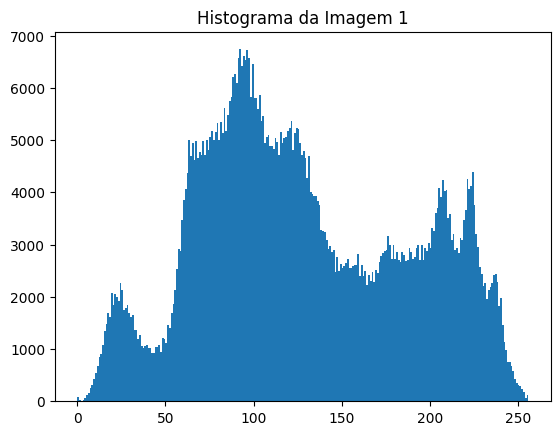

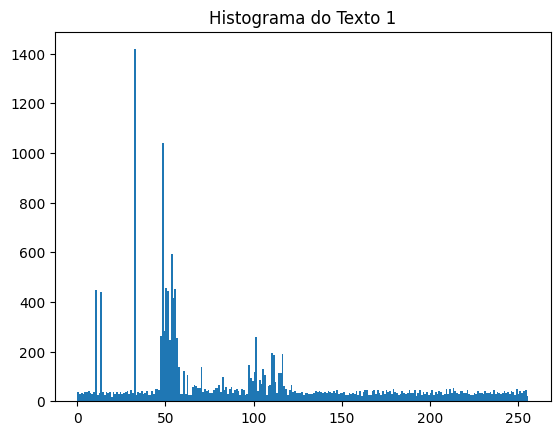

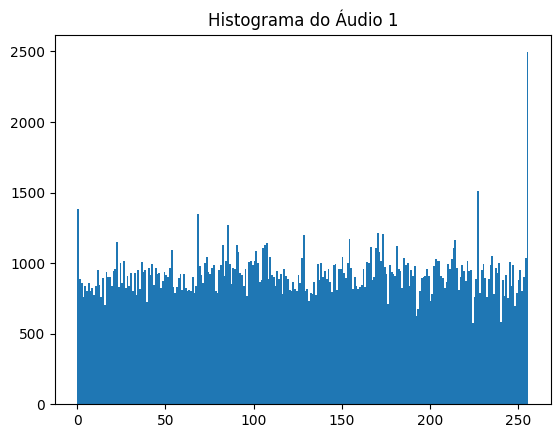

Tempo de execução para gerar a tabela Huffman da imagem1: 0.0073 segundos
Tempo de execução para gerar a tabela Huffman do texto1: 0.0055 segundos
Tempo de execução para gerar a tabela Huffman do áudio1: 0.0041 segundos


In [385]:
image1 = np.fromfile(image1_path, dtype=np.uint8)
text1 = np.fromfile(text1_path, dtype=np.uint8)
audio1 = np.fromfile(audio1_path, dtype=np.uint8)

image1_h, image1_bins, image1_p = plt.hist(image1, bins=256, range=[0, 256])
plt.title("Histograma da Imagem 1")
plt.show()
text1_h, text1_bins, text1_p = plt.hist(text1, bins=256, range=[0, 256])
plt.title("Histograma do Texto 1")
plt.show()
audio1_h, audio1_bins, audio1_p = plt.hist(audio1, bins=256, range=[0, 256])
plt.title("Histograma do Áudio 1")
plt.show()

image1_Px = image1_h / image1_h.sum()
image1_Ax = np.arange(256)

text1_Px = text1_h / text1_h.sum()
text1_Ax = np.arange(256)

audio1_Px = audio1_h / audio1_h.sum()
audio1_Ax = np.arange(256)

time0 = time()
huff_dict_image = gen_huff_table(image1_Ax, image1_Px)
time1 = time()
print(f"Tempo de execução para gerar a tabela Huffman da imagem1: {time1 - time0:.4f} segundos")

time0 = time()
huff_dict_text = gen_huff_table(text1_Ax, text1_Px)
time1 = time()
print(f"Tempo de execução para gerar a tabela Huffman do texto1: {time1 - time0:.4f} segundos")

time0 = time()
huff_dict_audio = gen_huff_table(audio1_Ax, audio1_Px)
time1 = time()
print(f"Tempo de execução para gerar a tabela Huffman do áudio1: {time1 - time0:.4f} segundos")

## 7b

In [386]:
def calcular_entropia(probs):
    # Filtrar probabilidades zero para evitar erro no log2
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

def calcular_num_medio_bits(huff_dict, probs_dict):
    # L_avg = somatório de (Probabilidade_i * Comprimento_Código_i)
    l_avg = 0
    for simbolo, codigo in huff_dict.items():
        # Multiplica a probabilidade do símbolo pelo tamanho do seu código
        l_avg += probs_dict[simbolo] * len(codigo)
    return l_avg

# --- Processamento para IMAGEM ---
# Criar dicionário de probabilidades para facilitar a busca
prob_dict_img1 = dict(zip(image1_Ax, image1_Px))

h_img = calcular_entropia(image1_Px)
l_avg_img = calcular_num_medio_bits(huff_dict_image, prob_dict_img1)
eficiencia_img = (h_img / l_avg_img) * 100 # Cálculo da eficiência 

print(f'Entropia da imagem: {h_img:.4f} bits/símbolo')
print(f'Número médio de bits (L_avg) da imagem: {l_avg_img:.4f} bits/símbolo')
print(f'Eficiência da imagem: {eficiencia_img:.2f}%')

Entropia da imagem: 7.7514 bits/símbolo
Número médio de bits (L_avg) da imagem: 7.7818 bits/símbolo
Eficiência da imagem: 99.61%


## 7c

In [387]:
t0 = time()
image1_encoded_string = encode_huff(image1, huff_dict_image)
t1 = time()

t0 = time()
text1_encoded_string = encode_huff(text1, huff_dict_text)
t1 = time()

t0 = time()
audio1_encoded_string = encode_huff(audio1, huff_dict_audio)
t1 = time()

print(f"Tempo de codificação da imagem: {t1 - t0:.4f} segundos")
print(f"Tempo de codificação do texto: {t1 - t0:.4f} segundos")
print(f"Tempo de codificação do áudio: {t1 - t0:.4f} segundos")

Tempo de codificação da imagem: 0.0752 segundos
Tempo de codificação do texto: 0.0752 segundos
Tempo de codificação do áudio: 0.0752 segundos


## 7.d

In [388]:
encoded_table_image1 = encode_table(huff_dict_image)
encoded_table_text1 = encode_table(huff_dict_text)
encoded_table_audio1 = encode_table(huff_dict_audio)

image1_encoded_string_table = encoded_table_image1 + image1_encoded_string
text1_encoded_string_table = encoded_table_text1 + text1_encoded_string
audio1_encoded_string_table = encoded_table_audio1 + audio1_encoded_string

write2file(image1_encoded_string_table, "7d_output.bin")
write2file(text1_encoded_string_table, "7d_output_text.bin")
write2file(audio1_encoded_string_table, "7d_output_audio.bin")

with open("7d_output.bin", "rb") as f:
    aux = f.read()
    image1_encoded_file = ''.join(f'{byte:08b}' for byte in aux)
    
with open("7d_output_text.bin", "rb") as f:
    aux = f.read()
    text1_encoded_file = ''.join(f'{byte:08b}' for byte in aux)
    
with open("7d_output_audio.bin", "rb") as f:
    aux = f.read()
    audio1_encoded_file = ''.join(f'{byte:08b}' for byte in aux)
    
with open(image1_path, "rb") as f:
    aux = f.read()
    image1_bits = ''.join(f'{byte:08b}' for byte in aux)
    
with open(text1_path, "rb") as f:
    aux = f.read()
    text1_bits = ''.join(f'{byte:08b}' for byte in aux)
    
with open(audio1_path, "rb") as f:
    aux = f.read()
    audio1_bits = ''.join(f'{byte:08b}' for byte in aux)

print(f"Comprimento da imagem codificada: {len(image1_encoded_file)} bits")
print(f"Comprimento da imagem original: {len(image1_bits)} bits")
print(f"Taxa de compressão: {len(image1_encoded_file) / len(image1_bits):.4f}\n")

print(f"Comprimento do texto codificado: {len(text1_encoded_file)} bits")
print(f"Comprimento do texto original: {len(text1_bits)} bits")
print(f"Taxa de compressão: {len(text1_encoded_file) / len(text1_bits):.4f}\n")

print(f"Comprimento do áudio codificado: {len(audio1_encoded_file)} bits")
print(f"Comprimento do áudio original: {len(audio1_bits)} bits")
print(f"Taxa de compressão: {len(audio1_encoded_file) / len(audio1_bits):.4f}\n")

Comprimento da imagem codificada: 6126464 bits
Comprimento da imagem original: 6292576 bits
Taxa de compressão: 0.9736

Comprimento do texto codificado: 129408 bits
Comprimento do texto original: 140192 bits
Taxa de compressão: 0.9231

Comprimento do áudio codificado: 1899248 bits
Comprimento do áudio original: 1895400 bits
Taxa de compressão: 1.0020



## 7. e

In [389]:
# Ler ficheiro e descodificar a tabela 
tabela_codigo_img, seq_bit1_img = read_file("7d_output.bin")

print(seq_bit1_img == image1_encoded_string)
 
tabela_codigo_text, seq_bit1_text = read_file("7d_output_text.bin")

print(seq_bit1_text == text1_encoded_string)

tabela_codigo_audio, seq_bit1_audio = read_file("7d_output_audio.bin")

print(seq_bit1_audio == audio1_encoded_string)

True
True
True


In [390]:
# Descodificar a mensagem
t0 = time()
decoded_msg = decode_huff(seq_bit1_img, tabela_codigo_img) 
t1 = time()
print(f"Tempo de descodificação: {t1 - t0:.4f} segundos")


Tempo de descodificação: 1.0264 segundos


In [391]:
t0 = time()
decoded_msg_text = decode_huff(seq_bit1_text, tabela_codigo_text) 
t1 = time()
print(f"Tempo de descodificação: {t1 - t0:.4f} segundos")

Tempo de descodificação: 0.0283 segundos


In [392]:
t0 = time()
decoded_msg_audio = decode_huff(seq_bit1_audio, tabela_codigo_audio) 
t1 = time()
print(f"Tempo de descodificação: {t1 - t0:.4f} segundos")

Tempo de descodificação: 0.4579 segundos


## 7 g

In [396]:
print("A imagem recuperada é igual à original?")
print(np.array_equal(image1, decoded_msg)) 

print("O texto recuperado é igual ao original?")
print(np.array_equal(text1, decoded_msg_text))

A imagem recuperada é igual à original?
True
O texto recuperado é igual ao original?
True


In [394]:


# Criar uma lista de dicionários com os resultados
resultados_validacao = [
    {
        "Ficheiro": "Imagem (Lena)",
        "Original (Símbolos)": len(image1),
        "Recuperado (Símbolos)": len(decoded_msg),
        "Erro Nulo?": np.array_equal(image1, decoded_msg)
    },
    {
        "Ficheiro": "Texto (DecUniversal)",
        "Original (Símbolos)": len(text1),
        "Recuperado (Símbolos)": len(decoded_msg_text),
        "Erro Nulo?": np.array_equal(text1, decoded_msg_text)
    },
    {
        "Ficheiro": "Áudio (PinkPanther)",
        "Original (Símbolos)": len(audio1),
        "Recuperado (Símbolos)": len(decoded_msg_audio),
        "Erro Nulo?": np.array_equal(audio1, decoded_msg_audio)
    }
]

# Criar o DataFrame
df_validacao = pd.DataFrame(resultados_validacao)

# Exibir a tabela formatada
print("Verificação de Integridade (Ponto 7.g):")
display(df_validacao) # Se estiver no Jupyter/Colab
# Ou print(df_validacao)

Verificação de Integridade (Ponto 7.g):


,Ficheiro,Original (Símbolos),Recuperado (Símbolos),Erro Nulo?
0,Imagem (Lena),786572,786572,True
1,Texto (DecUniversal),17524,17524,True
2,Áudio (PinkPanther),236925,236925,True
